# ContinuousTimeRNN Testing

Quick sanity-check notebook for the refactored API:
- `InputGenerator.generate()` returns a `TsGroup` of Poisson spike trains
- `ContinuousTimeRNN.__call__` embeds the alpha-kernel convolution internally
- `Simulator` is a thin wrapper around the system callable

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import neurosignature as ns
import seaborn as sns

np.random.seed(1)
sns.set_context("notebook")
plt.rcParams["axes.formatter.useoffset"] = False

## 1. Build the CTRNN

In [26]:
n_hidden = 16
n_inputs = 3
n_outputs = 4
dt_ms = 1.0

W_int = ns.generate_random_matrix(
    n_hidden, n_hidden, dist="normal", matrix_type="symmetric"
)
W_prop = ns.generate_random_matrix(
    n_hidden, n_hidden, dist="normal", matrix_type="symmetric"
)
W_u = ns.relu(
    ns.generate_random_matrix(n_hidden, n_inputs, dist="normal", matrix_type="dense")
)
W_o = ns.relu(
    ns.generate_random_matrix(n_outputs, n_hidden, dist="normal", matrix_type="dense")
)

system = ns.ContinuousTimeRNN(
    n_hidden=n_hidden,
    n_inputs=n_inputs,
    n_outputs=n_outputs,
    W_int=W_int,
    W_prop=W_prop,
    W_u=W_u,
    W_o=W_o,
    g=0.05,
    tau=5.0,
    V_rest=-65.0,
    polarity="excitatory",
    phi="tanh",
    tau_syn_ms=5.0,
    dt_ms=dt_ms,
)

print(system)

## 2. Generate Inputs & Run Simulation

In [27]:
input_gen = ns.InputGenerator(
    n_channels=n_inputs,
    rate_hz=50.0,
    dt_ms=dt_ms,
    seed=1,
)

duration_ms = 500.0
ts_group = input_gen.generate(duration_ms=duration_ms)

simulator = ns.Simulator(system)
outputs = simulator.run(ts_group)

time_ms = np.asarray(outputs.index) * 1000.0
outputs_arr = np.asarray(outputs)

print(f"Input channels : {len(ts_group)}")
print(f"Outputs shape  : {outputs.shape}")
print(f"Output range   : [{outputs_arr.min():.3f}, {outputs_arr.max():.3f}] mV")

Input channels : 3
Outputs shape  : (500, 4)
Output range   : [-65.000, -50.125] mV


## 3. Plot

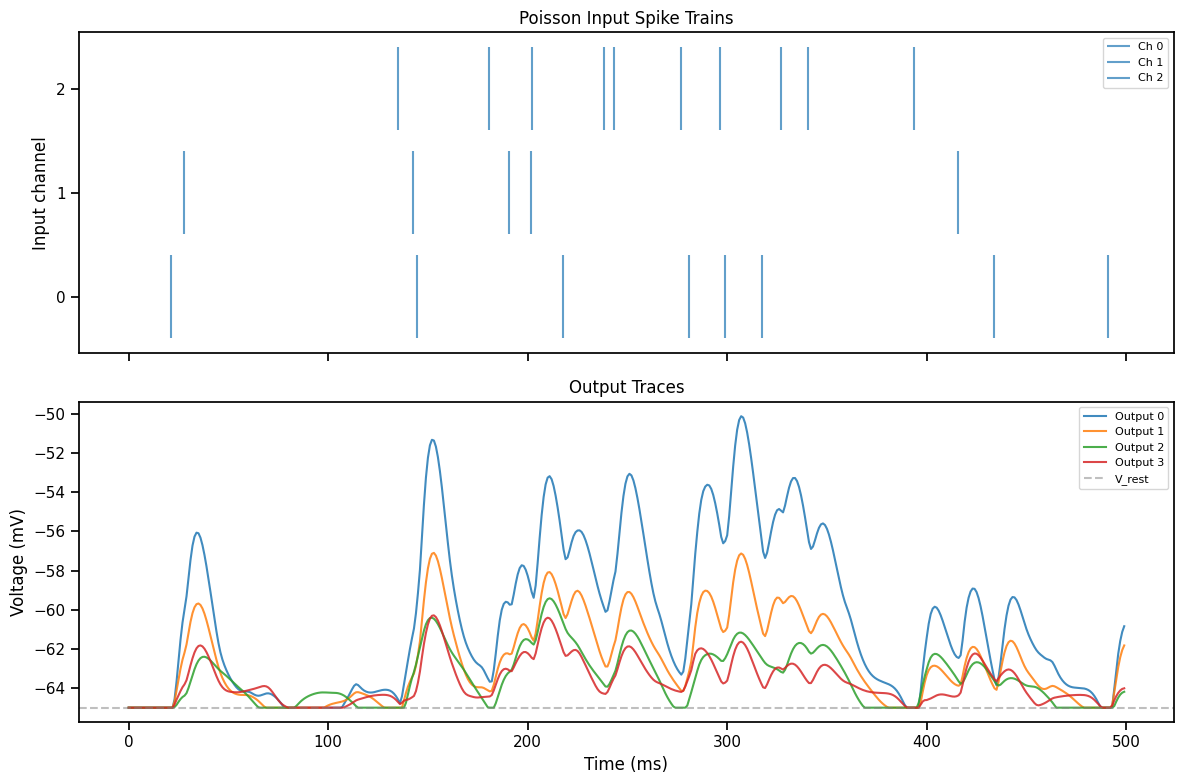

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Spike raster
ax = axes[0]
for key in sorted(ts_group.keys()):
    spike_times_ms = ts_group[key].index * 1000.0
    ax.vlines(
        spike_times_ms,
        key - 0.4,
        key + 0.4,
        linewidth=1.5,
        alpha=0.7,
        label=f"Ch {key}",
    )
ax.set_ylabel("Input channel")
ax.set_title("Poisson Input Spike Trains")
ax.set_yticks(sorted(ts_group.keys()))
ax.legend(loc="upper right", fontsize=8)

# Output traces
ax = axes[1]
for i in range(n_outputs):
    ax.plot(time_ms, outputs_arr[:, i], label=f"Output {i}", alpha=0.85)
ax.axhline(system.V_rest, color="gray", linestyle="--", alpha=0.5, label="V_rest")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Voltage (mV)")
ax.set_title("Output Traces")
ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()